
# Decision Tree Classifier

## Step 1 - Import Libraries

In [1]:

import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt



## Step 2 - Load Iris Dataset from Seaborn

We will use only the feature columns from seaborn.


In [2]:

iris_df = sns.load_dataset("iris")

iris_df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,6.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,6.0,3.6,1.4,0.2,setosa



## Step 3 - Extract X Features from Seaborn Dataset


In [3]:

X = iris_df.drop(
    columns=["species"]
)

X.head()


,sepal_length,sepal_width,petal_length,petal_width
0,6.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,6.0,3.6,1.4,0.2



## Step 4 - Load Target (y) from Scikit-Learn Iris Dataset

Target Mapping:

0 = Setosa

1 = Versicolor

2 = Virginica


In [4]:

iris_sklearn = load_iris()

# X = iris_sklearn.data
y = iris_sklearn.target

print(y)


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]



## Step 5 - Understand Dataset Shapes


In [5]:

print("X Shape:", X.shape)

print("y Shape:", y.shape)


X Shape: (150, 4)
y Shape: (150,)



## Step 6 - Explore Class Distribution


In [6]:

pd.Series(y).value_counts()


,count
0,50
1,50
2,50



## Step 7 - Train Test Split


In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)


Training Shape: (105, 4)
Testing Shape : (45, 4)



## Step 8 - Create Decision Tree Classifier

criterion='gini'


In [8]:

model = DecisionTreeClassifier(random_state=42)

model


DecisionTreeClassifier(random_state=42)


## Step 9 - Train the Model


In [9]:

model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")


Model Trained Successfully



## Step 10 - Make Predictions


In [10]:

predictions = model.predict(X_test)

print(predictions[:10])


[1 0 2 1 1 0 1 2 1 1]



## Step 11 - Accuracy Score


In [11]:

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)


Accuracy: 1.0



## Step 12 - Visualize Decision Tree


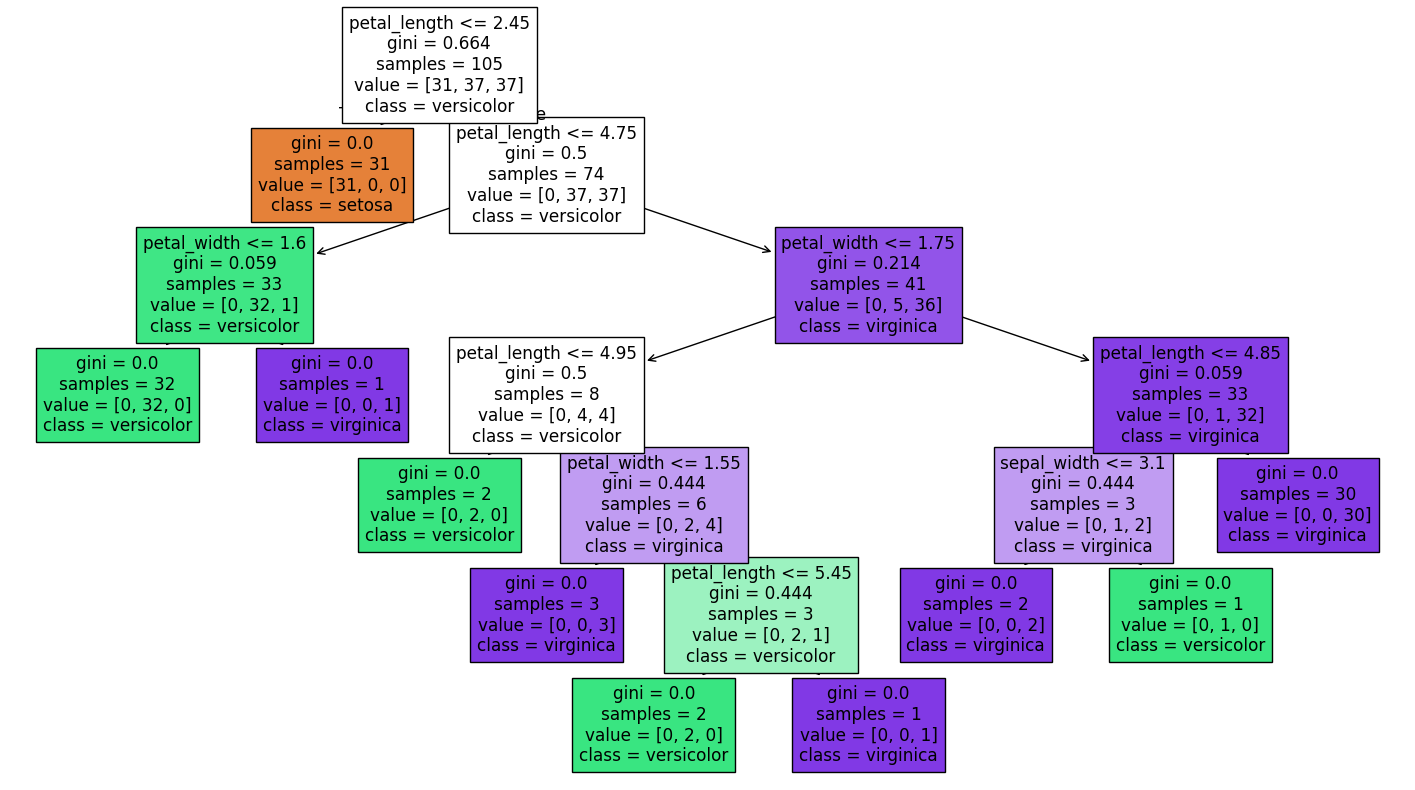

In [20]:

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=iris_sklearn.target_names,
    filled=True
)

plt.show()



## Step 13 - Feature Importance


In [13]:

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)


,Feature,Importance
2,petal_length,0.893264
3,petal_width,0.087626
1,sepal_width,0.019110
0,sepal_length,0.000000


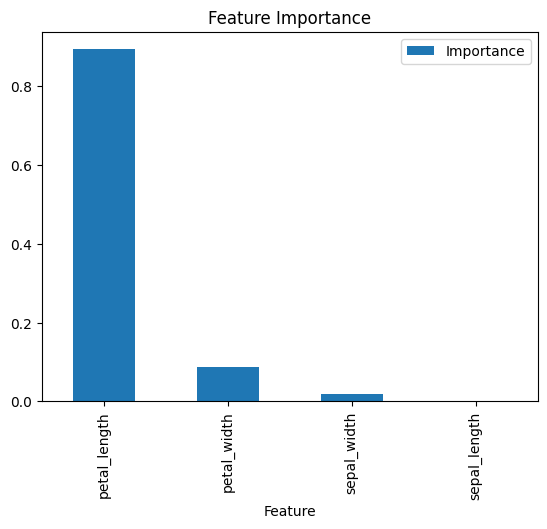

In [14]:

importance.sort_values(
    by='Importance',
    ascending=False
).plot(
    x='Feature',
    y='Importance',
    kind='bar'
)

plt.title("Feature Importance")

plt.show()



## Step 14 - Predict a New Flower


In [15]:

new_flower = [[
    6.1,
    3.5,
    1.4,
    0.2
]]

prediction = model.predict(
    new_flower
)

species = iris_sklearn.target_names[
    prediction[0]
]

print("Predicted Species:", species)


Predicted Species: setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



## Step 15 - Compare Gini vs Entropy


In [16]:

gini_model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

entropy_model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

gini_model.fit(X_train,y_train)
entropy_model.fit(X_train,y_train)

gini_pred = gini_model.predict(X_test)
entropy_pred = entropy_model.predict(X_test)

print(
    "Gini Accuracy:",
    accuracy_score(
        y_test,
        gini_pred
    )
)

print(
    "Entropy Accuracy:",
    accuracy_score(
        y_test,
        entropy_pred
    )
)


Gini Accuracy: 1.0
Entropy Accuracy: 0.9777777777777777



## Step 16 - Hyperparameter Tuning Example


In [17]:

tuned_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

tuned_model.fit(
    X_train,
    y_train
)

tuned_predictions = tuned_model.predict(
    X_test
)

print(
    "Tuned Accuracy:",
    accuracy_score(
        y_test,
        tuned_predictions
    )
)


Tuned Accuracy: 1.0



## Step 17 - Understanding Overfitting

Very deep tree:

max_depth=None

May memorize training data.

Controlled tree:

max_depth=3 or 4

Usually generalizes better.
